In [38]:
data = pd.read_csv(file_path)

print(data.shape)
data.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [37]:
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
data_clean.to_csv(
    PROCESSED_DIR / "telco_customer_clean.csv",
    index=False
)

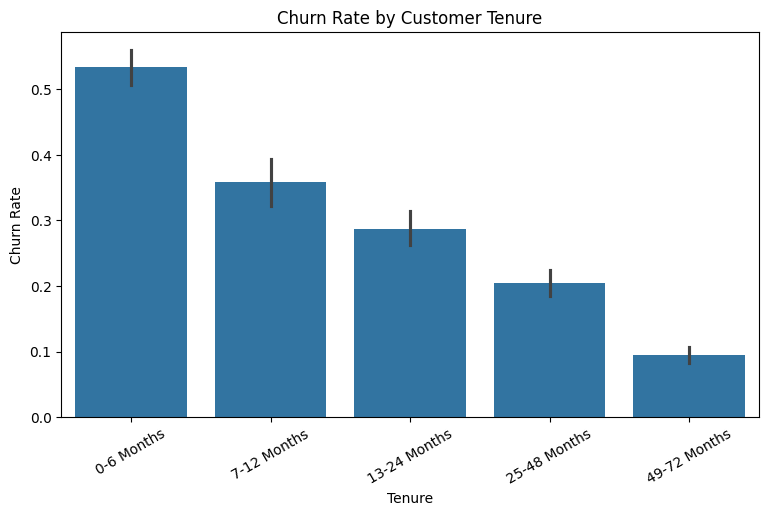

In [35]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=data_clean,
    x="Tenure_Group",
    y="Churn_Target"
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure")
plt.ylabel("Churn Rate")

plt.xticks(rotation=30)

plt.show()

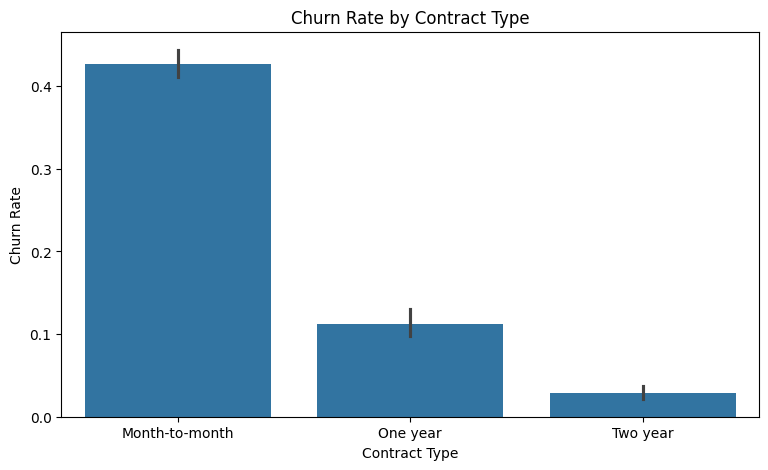

In [34]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=data_clean,
    x="Contract",
    y="Churn_Target"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate")

plt.show()

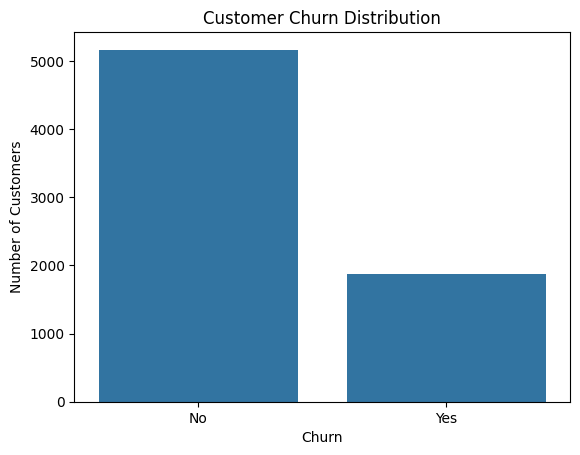

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(
    data=data_clean,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

In [32]:
data_clean["Tenure_Group"] = pd.cut(
    data_clean["tenure"],
    bins=[0, 6, 12, 24, 48, 72],
    labels=[
        "0-6 Months",
        "7-12 Months",
        "13-24 Months",
        "25-48 Months",
        "49-72 Months"
    ],
    include_lowest=True
)

tenure_churn = (
    data_clean
    .groupby("Tenure_Group", observed=True)["Churn_Target"]
    .mean()
    .mul(100)
)

tenure_churn

payment_churn = (
    data_clean
    .groupby("PaymentMethod")["Churn_Target"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

payment_churn

data_clean.groupby("Churn")["MonthlyCharges"].agg(
    ["mean", "median", "min", "max"]
)

,mean,median,min,max
Churn,,,,
No,61.307408,64.45,18.25,118.75
Yes,74.441332,79.65,18.85,118.35


In [26]:
contract_churn = (
    data_clean
    .groupby("Contract")["Churn_Target"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

contract_churn

Contract
Month-to-month    42.709677
One year          11.277174
Two year           2.848665
Name: Churn_Target, dtype: float64

In [25]:

churn_rate = data_clean["Churn_Target"].mean() * 100

print(f"Overall churn rate: {churn_rate:.2f}%")

monthly_revenue = data_clean["MonthlyCharges"].sum()

print(f"Monthly revenue represented: ${monthly_revenue:,.2f}")

print(
    f"Average monthly charge: "
    f"${data_clean['MonthlyCharges'].mean():.2f}"
)

Overall churn rate: 26.58%
Monthly revenue represented: $455,661.00
Average monthly charge: $64.80


In [21]:
data_clean["Churn_Target"] = (
    data_clean["Churn"]
    .map({
        "Yes": 1,
        "No": 0
    })
)
data_clean["Churn_Target"].value_counts()

Churn_Target
0    5163
1    1869
Name: count, dtype: int64

In [19]:
print("Original rows:", len(data))
print("Clean rows:", len(data_clean))

Original rows: 7043
Clean rows: 7032


In [2]:
from pathlib import Path

PROJECT_DIR = Path(r"C:\Lang\Clg\StreamSense")

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
OUTPUT_DIR = PROJECT_DIR / "outputs"

print("Raw data:", RAW_DIR)
print("Files:")
for file in RAW_DIR.iterdir():
    print(file.name)

Raw data: C:\Lang\Clg\StreamSense\data\raw
Files:
WA_Fn-UseC_-Telco-Customer-Churn.csv


In [1]:
import pandas as pd
import numpy as np

print("StreamSense is ready!")

StreamSense is ready!
